# B 样条拟合

B 样条（B-spline）是样条函数的一种标准化，参数化形式，全称为基样条（Basic Spline）, 它解决了传统样条（如三次样条）在节点调整，局部性控制上的缺陷，是计算机图形学，机器人路径规划等领域的核心工具

## B样条的定义

给定一组节点向量 $T = \{ t_0, t_1,..., t_m \}$ ，k阶（次数为k-1）B样条的基函数 $N_{i,k}(t)$ 由递推公式定义：

1. 0阶B样条（k=1, 次数0）：分段常数函数 
   $$
   N_{i, 1}(t) = \begin{Bmatrix} 1, & t_i <= t < t_{i+1} \\ 0, & 其他 
   \end{Bmatrix}
   $$
2. 高阶B样条(k>1): 递推生成 $N_{i,k}(t) = \frac {} {} N_{i, k-1}(t) + \frac {t_{i+k} - t} {t{i+k}-t_{i+1}} N_{i+1, k-1}(t)$

最终，k阶B样条曲线是这些基函数的线性组合

$$
C(t) = \sum_{i=0}^{n}P_iN_{i,k}(t)
$$

其中：
+ $P_i$ 是控制点，决定曲线的大致形状
+ $t \in [t_{k-1}, t_{m-k+1}]$ 是参数，控制曲线上的点位置
+ 节点向量的长度 m = n + k (n+1个控制点对应m+1个节点)

## B样条的关键概念

### 节点向量的类型

+ 均匀B样条：节点间隔相等（如{0，1，2，3，4}，曲线均匀平滑
+ 非均匀B样条：节点间隔不等，可能需要的位置加密节点，提升局部拟合精度
+ 准均匀B样条：两端节点重复k次，中间节点均匀分布（最常用，保证曲线首尾穿过首位控制点）

### 次数和节点重复度

+ 次数为 d = k - 1 (比如k=4对应三次B样条，工程中最常用)
+ 节点重复度：若某个节点出现r次，曲线在该节点处的光滑性降为 d-r+1 阶导数连续
+ 例：三次B样条（d=3）中，若节点 $t_i$ 重复2次，则该点处二阶导数不连续，一阶导数连续

### 插值和拟合的切换

+ 传统 B 样条是拟合曲线（不穿过控制点）
+ 若要让B样条穿过指定点（插值），只需要通过求解方程组，反推出满足条件的控制点即可（成为B样条插值）


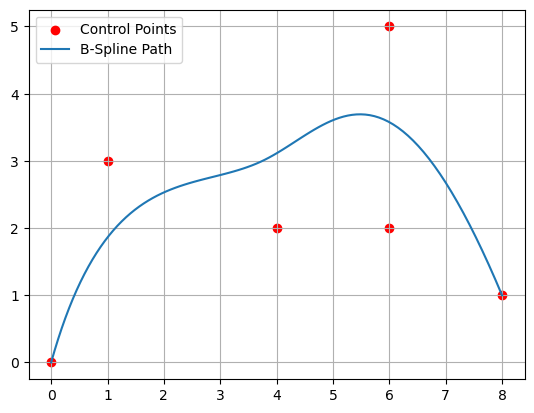

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline

# 1. 定义控制点（比如机器人的关键路径点）
P = np.array([[0, 0], [1, 3], [4, 2], [6, 5], [8, 1], [6, 2]])
x_p, y_p = P[:, 0], P[:, 1]

# 2. 定义节点向量（准均匀节点，次数3，k=4)
n = len(P) - 1 # 控制点数量-1
k = 4          # B样条阶数 = 次数 + 1
t = np.concatenate([
    np.zeros(k-1), # 首节点重复k-1次
    np.linspace(0, 1, n - k + 2), # 中间节点均匀分布
    np.ones(k-1)   # 末节点重复k-1次
])

# 3. B样条基函数定义
t_fine = np.linspace(0, 1, 100)   # 密集参数点
bs_x = BSpline(t, x_p, k-1)       # x方向B样条
bs_y = BSpline(t, y_p, k-1)       # y方向B样条
x_fine = bs_x(t_fine)
y_fine = bs_y(t_fine)

# 4. 可视化
plt.scatter(x_p, y_p, color='red', label='Control Points')
plt.plot(x_fine, y_fine, label='B-Spline Path')
plt.legend()
plt.grid(True)
plt.show()